# Compressed Sensing using Generative Models (Bora et al., 2017)
## A (didactic?) notebook in PyTorch

In [23]:
import yaml
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from pl_modules import plVAE as VAE
from datasets import MNISTDataModule

In [2]:
with open('./lightning_logs/version_0/hparams.yaml', 'r') as file:
    params = yaml.safe_load(file)
    
pl_model = VAE(
    input_dim=params['input_dim'],
    latent_dim=params['latent_dim']
)

checkpoint = torch.load('./checkpoints/vae-best-epoch.ckpt')
pl_model.load_state_dict(checkpoint['state_dict'])

<All keys matched successfully>

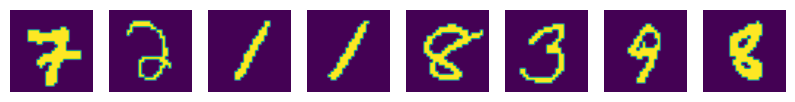

In [3]:
batch_size = 8
dataset = MNISTDataModule(batch_size)
val_data = dataset.val_dataloader()
batch = next(iter(val_data))

fig, axs = plt.subplots(1, batch_size, figsize=(10, 5))
for ax, img in zip(axs, batch[0]):
    ax.imshow(img[0])
    ax.axis('off')
plt.show()

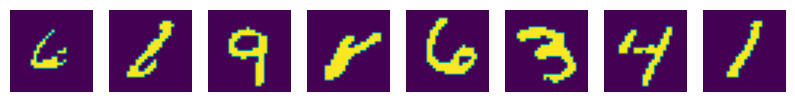

In [4]:
imgs = pl_model.model.sample(n_samples=batch_size)

fig, axs = plt.subplots(1, batch_size, figsize=(10, 5))
for ax, img in zip(axs, imgs):
    ax.imshow(img)
    ax.axis('off')
plt.show()

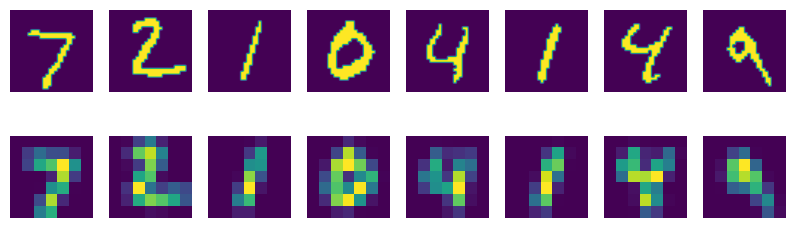

In [18]:
test_data = dataset.test_dataloader()
test_batch = next(iter(test_data))
lr_batch = dataset.hr2lr(test_batch[0])

fig, axs = plt.subplots(2, batch_size, figsize=(10, 3))
for ax, hr, lr in zip(axs.T, test_batch[0], lr_batch):
    ax[0].imshow(hr[0])
    ax[1].imshow(lr)
    ax[0].axis('off')
    ax[1].axis('off')
plt.show()

In [136]:
def inversion(
    z_init: torch.Tensor,
    y: torch.Tensor,
    A: callable,
    lr: float = 1e-4,
    n_it: int = 5000,
    l_reg: float = 1e-4,
    verbose: int = 500
    ):
    batch_size = y.shape[0]
    z = torch.nn.Parameter(z_init, requires_grad=True)
    optimizer = torch.optim.Adam([z], lr=lr)

    for it in range(n_it):
        x = pl_model.model.decode(z).view(-1, dataset.hr_size, dataset.hr_size)
        Ax = A(x)
        rec_loss = F.mse_loss(y, Ax)
        reg_loss = torch.sum(z**2, dim=-1).mean()
        loss = rec_loss + l_reg * reg_loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if it == 0 or (it + 1) % verbose == 0:
            print("It {}: rec loss = {:.4f} - reg loss = {:.2f} - tot loss = {:.4f}".format(it+1, rec_loss, reg_loss, loss))
    x = pl_model.model.decode(z).view(-1, dataset.hr_size, dataset.hr_size)
    rec = (x.detach() > 0.5).float()
    return rec

In [137]:
hyperparams = {
    'lr': 5e-4,
    'n_it': 10000,
    'l_reg': 0,
    'verbose': 500
}

In [138]:
z_init = 0.1 * torch.randn(batch_size, params['latent_dim'])
rec = inversion(z_init, lr_batch, dataset.hr2lr, **hyperparams)

It 1: rec loss = 0.0234 - reg loss = 0.34 - tot loss = 0.0234
It 500: rec loss = 0.0138 - reg loss = 1.39 - tot loss = 0.0138
It 1000: rec loss = 0.0109 - reg loss = 3.04 - tot loss = 0.0109
It 1500: rec loss = 0.0092 - reg loss = 5.08 - tot loss = 0.0092
It 2000: rec loss = 0.0080 - reg loss = 7.20 - tot loss = 0.0080
It 2500: rec loss = 0.0073 - reg loss = 9.77 - tot loss = 0.0073
It 3000: rec loss = 0.0064 - reg loss = 13.38 - tot loss = 0.0064
It 3500: rec loss = 0.0060 - reg loss = 17.13 - tot loss = 0.0060
It 4000: rec loss = 0.0058 - reg loss = 21.56 - tot loss = 0.0058
It 4500: rec loss = 0.0056 - reg loss = 26.70 - tot loss = 0.0056
It 5000: rec loss = 0.0055 - reg loss = 32.20 - tot loss = 0.0055
It 5500: rec loss = 0.0054 - reg loss = 38.26 - tot loss = 0.0054
It 6000: rec loss = 0.0044 - reg loss = 45.03 - tot loss = 0.0044
It 6500: rec loss = 0.0040 - reg loss = 51.63 - tot loss = 0.0040
It 7000: rec loss = 0.0039 - reg loss = 58.83 - tot loss = 0.0039
It 7500: rec loss = 

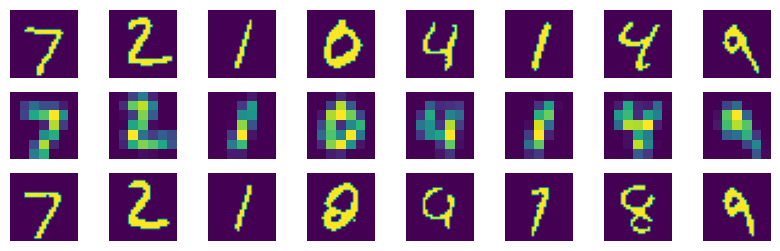

MSE: 0.0564


In [141]:
fig, axs = plt.subplots(3, batch_size, figsize=(10, 3))
for ax, hr_img, lr_img, rec_ in zip(axs.T, test_batch[0], lr_batch, rec):
    ax[0].imshow(hr_img[0])
    ax[1].imshow(lr_img)
    ax[2].imshow(rec_)
    ax[0].axis('off')
    ax[1].axis('off')
    ax[2].axis('off')
plt.show()

print("MSE: {:.4f}".format(F.mse_loss(test_batch[0].squeeze(1), rec).item()))

In [126]:
z = torch.nn.Parameter(0.1 * torch.randn(batch_size, params['latent_dim']), requires_grad=True)
optimizer = torch.optim.Adam([z], lr=lr)

for it in range(n_it):
    x = pl_model.model.decode(z).view(-1, dataset.hr_size, dataset.hr_size)
    rec_loss = F.mse_loss(test_batch[0].squeeze(1), x)
    reg_loss = torch.sum(z**2, dim=-1).mean()
    loss = rec_loss + l_reg * reg_loss
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    
    if it == 0 or (it + 1) % verbose == 0:
        print("It {}: rec loss = {:.4f} - reg loss = {:.2f} - tot loss = {:.4f}".format(it+1, rec_loss, reg_loss, loss))

It 1: rec loss = 0.0982 - reg loss = 0.31 - tot loss = 0.0983
It 500: rec loss = 0.0752 - reg loss = 1.21 - tot loss = 0.0753
It 1000: rec loss = 0.0638 - reg loss = 2.40 - tot loss = 0.0641
It 1500: rec loss = 0.0546 - reg loss = 3.74 - tot loss = 0.0550
It 2000: rec loss = 0.0493 - reg loss = 4.65 - tot loss = 0.0498
It 2500: rec loss = 0.0472 - reg loss = 5.03 - tot loss = 0.0477
It 3000: rec loss = 0.0453 - reg loss = 5.59 - tot loss = 0.0458
It 3500: rec loss = 0.0446 - reg loss = 5.62 - tot loss = 0.0451
It 4000: rec loss = 0.0440 - reg loss = 5.64 - tot loss = 0.0446
It 4500: rec loss = 0.0439 - reg loss = 5.55 - tot loss = 0.0444
It 5000: rec loss = 0.0438 - reg loss = 5.55 - tot loss = 0.0444
It 5500: rec loss = 0.0438 - reg loss = 5.61 - tot loss = 0.0443
It 6000: rec loss = 0.0437 - reg loss = 5.68 - tot loss = 0.0443
It 6500: rec loss = 0.0437 - reg loss = 5.77 - tot loss = 0.0443
It 7000: rec loss = 0.0436 - reg loss = 5.85 - tot loss = 0.0442
It 7500: rec loss = 0.0436 - 

In [143]:
z_init = 0.1 * torch.randn(batch_size, params['latent_dim'])
rec = inversion(z_init, test_batch[0].squeeze(1), lambda x: x, **hyperparams)

It 1: rec loss = 0.1018 - reg loss = 0.35 - tot loss = 0.1018
It 500: rec loss = 0.0795 - reg loss = 1.45 - tot loss = 0.0795
It 1000: rec loss = 0.0675 - reg loss = 3.81 - tot loss = 0.0675
It 1500: rec loss = 0.0580 - reg loss = 6.90 - tot loss = 0.0580
It 2000: rec loss = 0.0518 - reg loss = 10.85 - tot loss = 0.0518
It 2500: rec loss = 0.0468 - reg loss = 15.62 - tot loss = 0.0468
It 3000: rec loss = 0.0412 - reg loss = 20.74 - tot loss = 0.0412
It 3500: rec loss = 0.0364 - reg loss = 25.16 - tot loss = 0.0364
It 4000: rec loss = 0.0352 - reg loss = 29.63 - tot loss = 0.0352
It 4500: rec loss = 0.0345 - reg loss = 34.52 - tot loss = 0.0345
It 5000: rec loss = 0.0339 - reg loss = 39.97 - tot loss = 0.0339
It 5500: rec loss = 0.0336 - reg loss = 46.05 - tot loss = 0.0336
It 6000: rec loss = 0.0334 - reg loss = 53.10 - tot loss = 0.0334
It 6500: rec loss = 0.0332 - reg loss = 61.40 - tot loss = 0.0332
It 7000: rec loss = 0.0330 - reg loss = 70.85 - tot loss = 0.0330
It 7500: rec loss 

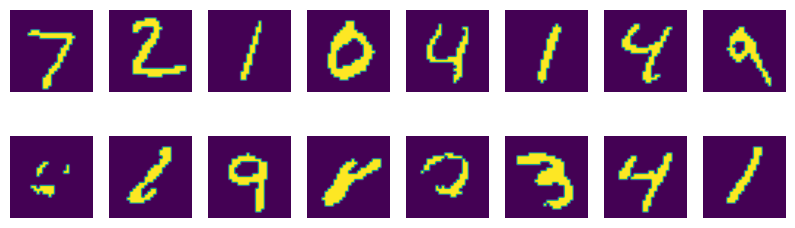

MSE: 0.1280


/tmp/ipykernel_380075/1607987033.py:9: UserWarning: Using a target size (torch.Size([28, 28])) that is different to the input size (torch.Size([8, 28, 28])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  print("MSE: {:.4f}".format(F.mse_loss(test_batch[0].squeeze(1), rec).item()))


In [144]:
fig, axs = plt.subplots(2, batch_size, figsize=(10, 3))
for ax, hr_img, lr_img, rec in zip(axs.T, test_batch[0], lr_batch, x.detach()):
    ax[0].imshow(hr_img[0])
    ax[1].imshow((rec > 0.5).float())
    ax[0].axis('off')
    ax[1].axis('off')
plt.show()

print("MSE: {:.4f}".format(F.mse_loss(test_batch[0].squeeze(1), rec).item()))

In [145]:
z_init = 0.1 * torch.randn(batch_size, params['latent_dim'])
rec = inversion(z_init, dataset.hr2lr(imgs), dataset.hr2lr, **hyperparams)

It 1: rec loss = 0.0283 - reg loss = 0.28 - tot loss = 0.0283
It 500: rec loss = 0.0191 - reg loss = 1.46 - tot loss = 0.0191
It 1000: rec loss = 0.0155 - reg loss = 3.86 - tot loss = 0.0155
It 1500: rec loss = 0.0122 - reg loss = 6.97 - tot loss = 0.0122
It 2000: rec loss = 0.0097 - reg loss = 10.20 - tot loss = 0.0097
It 2500: rec loss = 0.0080 - reg loss = 13.61 - tot loss = 0.0080
It 3000: rec loss = 0.0072 - reg loss = 16.87 - tot loss = 0.0072
It 3500: rec loss = 0.0057 - reg loss = 20.81 - tot loss = 0.0057
It 4000: rec loss = 0.0042 - reg loss = 25.62 - tot loss = 0.0042
It 4500: rec loss = 0.0036 - reg loss = 30.26 - tot loss = 0.0036
It 5000: rec loss = 0.0032 - reg loss = 35.21 - tot loss = 0.0032
It 5500: rec loss = 0.0024 - reg loss = 40.52 - tot loss = 0.0024
It 6000: rec loss = 0.0020 - reg loss = 45.43 - tot loss = 0.0020
It 6500: rec loss = 0.0018 - reg loss = 49.90 - tot loss = 0.0018
It 7000: rec loss = 0.0017 - reg loss = 54.00 - tot loss = 0.0017
It 7500: rec loss 

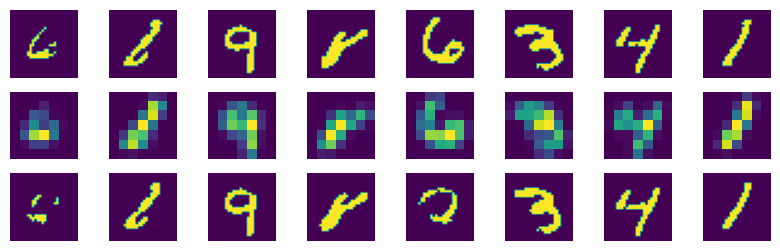

MSE: 0.0293


In [146]:
fig, axs = plt.subplots(3, batch_size, figsize=(10, 3))
for ax, hr_img, lr_img, rec in zip(axs.T, imgs, y, x.detach()):
    ax[0].imshow(hr_img)
    ax[1].imshow(lr_img)
    ax[2].imshow((rec > 0.5).float())
    ax[0].axis('off')
    ax[1].axis('off')
    ax[2].axis('off')
plt.show()

print("MSE: {:.4f}".format(F.mse_loss(imgs, (x.detach() > 0.5).float()).item()))